## HW 3 - Scraping and Regression

#### Linear Regressions exploring Hacker Rank
We will consider which columns in hn_stories.csv are the best candidates for influencing rank. 

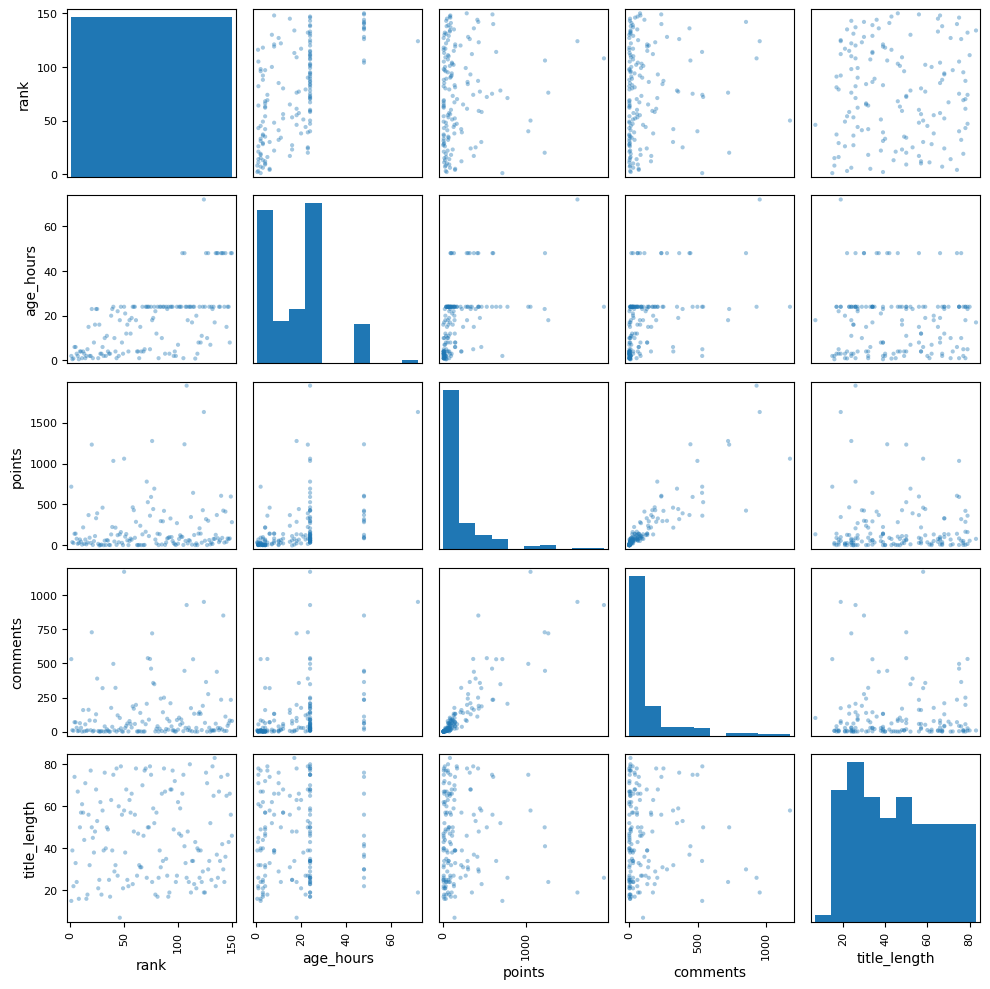

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

hnDFRaw = pd.read_csv("hn_stories.csv")

#I'm going to assume that story_id is an arbitrary number with no effect
cols = ['rank', 'age_hours', 'points', 'comments', 'title_length']

# Option A: pandas built-in (quick)
pd.plotting.scatter_matrix(hnDFRaw[cols], figsize=(10, 10), alpha=0.4)
plt.tight_layout()
plt.show()

This data isn't giving us a very clear picture. Some obsersations:
- title_length and rank seem uncorrelated, which fits my expectation. My assumption was title_length shouldn't matter.
- the points and comments graphs are similar, both showing clumps of data points near 0 for all rank values. So all rows with close to 0 points and comments are still represented across all ranks. 
- rank vs age_hours has a more noticeable trend where more recent stories are more represented at the top ranks and there is some clumping around 25 and 50 hours that may represent a significant effect.

But, onto the regressions.

In [13]:
import statsmodels.formula.api as smf

# The formula string: "outcome ~ predictor1 + predictor2"
# Left of ~ = what you're predicting
# Right of ~ = your predictors

# Regression 1: rank ~ points (simple)
model1 = smf.ols("rank ~ points", data=hnDFRaw).fit()
print(model1.summary())

# Regression 2: rank ~ points + comments (multiple)
model2 = smf.ols("rank ~ points + comments", data=hnDFRaw).fit()
print(model2.summary())

# # Regression 3: inverse linear — rank ~ 1/points
# # You create a new column first, then reference it
hnDFRaw['inv_points'] = 1 / (hnDFRaw['points'] + 1)  # +1 avoids division by zero
model3 = smf.ols("rank ~ inv_points", data=hnDFRaw).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                   rank   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.050
Date:                Sun, 07 Jun 2026   Prob (F-statistic):              0.307
Time:                        22:12:55   Log-Likelihood:                -777.53
No. Observations:                 150   AIC:                             1559.
Df Residuals:                     148   BIC:                             1565.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     73.1775      4.209     17.387      0.0